In [31]:
import pandas as pd

In [32]:
from pathlib import Path

# project root
root = Path.cwd().parent

file_path = root / "dwelling-unit.xlsx"

In [33]:
df = pd.read_excel(file_path)

In [34]:
file_path2 = root / "value-of-building-work-approved.xlsx"
df2= pd.read_excel(file_path2)

In [35]:
df2.tail()

,Dates,Total value of building jobs NSW,Total value of building jobs Victoria,Total value of building jobs Queensland,Total value of building jobs SA,Total value of building jobs WA,Total value of building jobs Tasmania,Total value of building jobs Northern Territory,Total value of building jobs Australian Capital Territory
626,2025-09-01,5609052,5001807,3458623,1352211,1815893,206528,75377,49010
627,2025-10-01,4775675,5160127,3393621,1091397,1963846,182609,130852,1182746
628,2025-11-01,4668719,5836405,4714203,836705,1672483,156542,67933,439114
629,2025-12-01,4815245,4754360,3089985,736944,2042743,334291,77063,515886
630,2026-01-01,4182606,3942600,2451803,1021695,1674453,135475,38781,86471


In [36]:
df.tail()

,Dates,Total number of dwelling units NSW,Total number of dwelling units Victoria,Total number of dwelling units Queensland,Total number of dwelling units SA,Total number of dwelling units WA,Total number of dwelling units Tasmania,Total number of dwelling units Northern Territory,Total number of dwelling units Australian Capital Territory
506,2025-09-01,4776,5576,3323,1131,1912,242,63,404
507,2025-10-01,3753,4207,3471,1274,2251,210,66,384
508,2025-11-01,4855,5113,4587,1279,2152,196,67,357
509,2025-12-01,4119,3595,3712,1281,2119,220,66,324
510,2026-01-01,3907,3200,3489,1162,2410,251,63,318


In [37]:
df2.dtypes

Dates                                                        datetime64[ns]
Total value of building jobs NSW                                      int64
Total value of building jobs Victoria                                 int64
Total value of building jobs Queensland                               int64
Total value of building jobs SA                                       int64
Total value of building jobs WA                                       int64
Total value of building jobs Tasmania                                 int64
Total value of building jobs Northern Territory                       int64
Total value of building jobs Australian Capital Territory             int64
dtype: object

In [38]:
merged_df = pd.merge(df, df2, on=["Dates"], how="inner")

In [39]:
merged_df.head()

,Dates,Total number of dwelling units NSW,Total number of dwelling units Victoria,Total number of dwelling units Queensland,Total number of dwelling units SA,Total number of dwelling units WA,Total number of dwelling units Tasmania,Total number of dwelling units Northern Territory,Total number of dwelling units Australian Capital Territory,Total value of building jobs NSW,Total value of building jobs Victoria,Total value of building jobs Queensland,Total value of building jobs SA,Total value of building jobs WA,Total value of building jobs Tasmania,Total value of building jobs Northern Territory,Total value of building jobs Australian Capital Territory
0,1983-07-01,2991,2843,2264,909,886,241,259,159,268644,206690,148955,58106,80906,18443,25245,23284
1,1983-08-01,3295,2907,2503,1007,1280,282,233,152,285958,273036,215111,78072,95669,16652,28153,21768
2,1983-09-01,3272,2889,2747,973,1539,298,212,150,300243,207176,249478,83887,92972,14756,13202,18000
3,1983-10-01,3423,3008,2825,1115,1432,293,195,152,263133,217843,296159,66230,68968,21286,11793,29864
4,1983-11-01,3374,2951,2685,1008,1400,296,188,159,306621,267592,194621,73094,79050,20929,18303,32363


In [40]:
merged_df.columns

Index(['Dates', 'Total number of dwelling units NSW',
       'Total number of dwelling units Victoria',
       'Total number of dwelling units Queensland',
       'Total number of dwelling units SA',
       'Total number of dwelling units WA',
       'Total number of dwelling units Tasmania',
       'Total number of dwelling units Northern Territory',
       'Total number of dwelling units Australian Capital Territory',
       'Total value of building jobs NSW',
       'Total value of building jobs Victoria ',
       'Total value of building jobs Queensland ',
       'Total value of building jobs SA', 'Total value of building jobs WA',
       'Total value of building jobs Tasmania',
       'Total value of building jobs Northern Territory',
       'Total value of building jobs Australian Capital Territory'],
      dtype='object')

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

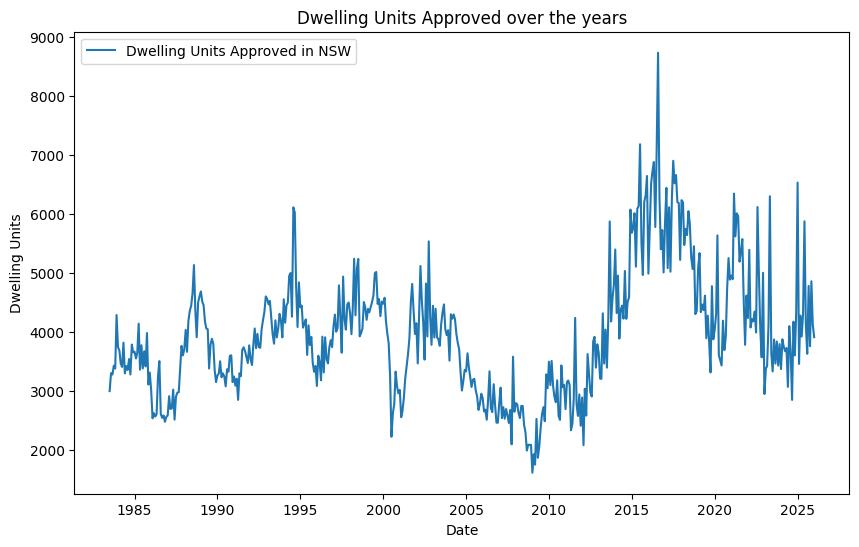

In [42]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=merged_df, x="Dates", y="Total number of dwelling units NSW", label="Dwelling Units Approved in NSW")
plt.xlabel('Date')
plt.ylabel('Dwelling Units')
plt.title('Dwelling Units Approved over the years')
plt.show()

In [43]:
df.set_index("Dates", inplace=True)

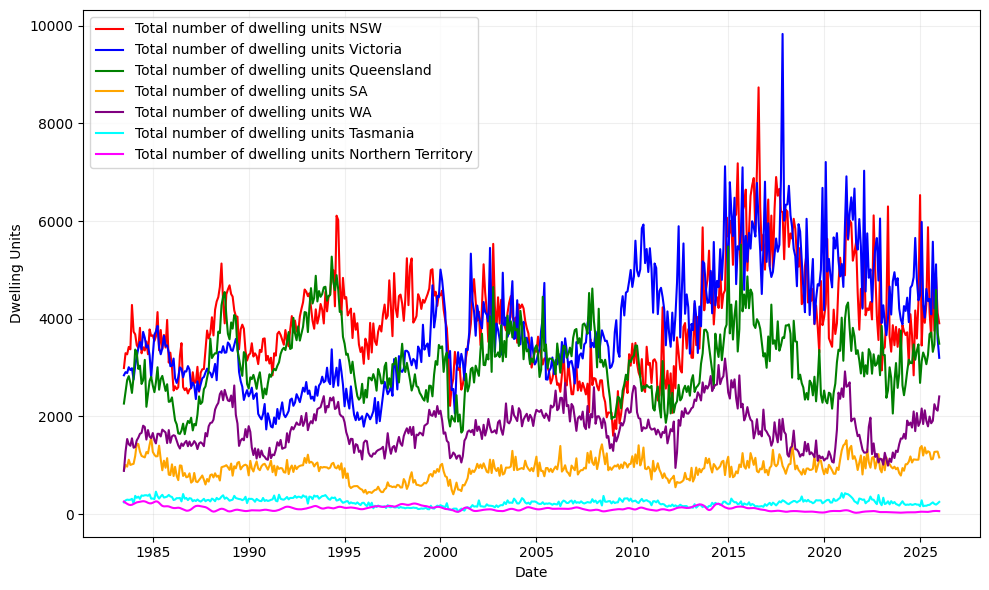

In [44]:
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
for col, color in zip(df, colors):
    plt.plot(df.index, df[col], label=col, color=color)
plt.xlabel('Date')
plt.ylabel('Dwelling Units')
plt.legend(df.columns, loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [45]:
df2.set_index("Dates", inplace=True)

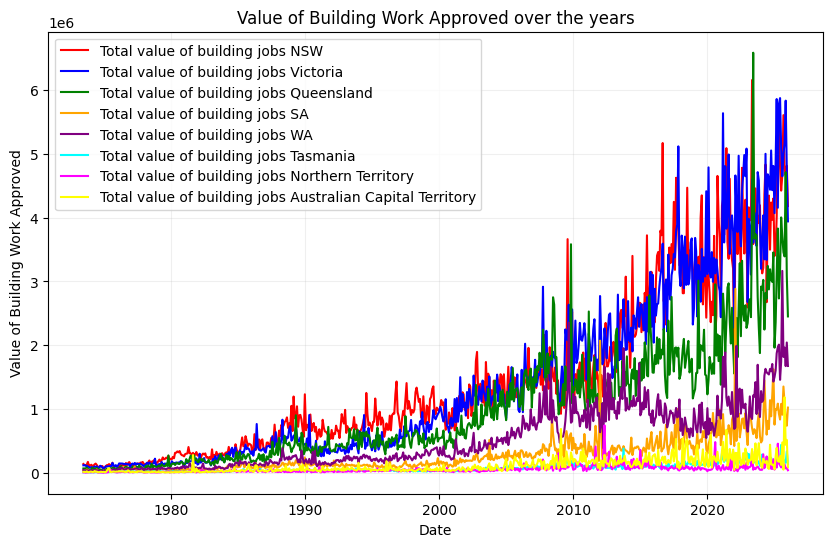

In [46]:
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']
for col, color in zip(df2, colors):
    plt.plot(df2.index, df2[col], label=col, color=color)
plt.xlabel('Date')
plt.ylabel('Value of Building Work Approved')
plt.title('Value of Building Work Approved over the years')
plt.legend(df2.columns, loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

In [47]:
import pandas as pd
from scipy.stats import zscore

states = ['NSW', 'Victoria', 'Queensland', 'WA']

for state in states:
    col = f'Total number of dwelling units {state}'
    df[f'{state}_zscore'] = zscore(df[col])

# Detect spikes
zscore_cols = [f'{s}_zscore' for s in states]
spikes = df[(abs(df[zscore_cols]) > 2).any(axis=1)]

print("Extreme approval spikes detected:")
print(spikes[[f'Total number of dwelling units {s}' for s in states]])  

Extreme approval spikes detected:
            Total number of dwelling units NSW  \
Dates                                            
1983-07-01                                2991   
1986-05-01                                2598   
1986-06-01                                3243   
1986-07-01                                3500   
1986-09-01                                2538   
...                                        ...   
2022-02-01                                5388   
2022-08-01                                6115   
2023-05-01                                6298   
2025-01-01                                6530   
2025-11-01                                4855   

            Total number of dwelling units Victoria  \
Dates                                                 
1983-07-01                                     2843   
1986-05-01                                     2806   
1986-06-01                                     3005   
1986-07-01                              

In [48]:
df.iloc[0:5]

,Total number of dwelling units NSW,Total number of dwelling units Victoria,Total number of dwelling units Queensland,Total number of dwelling units SA,Total number of dwelling units WA,Total number of dwelling units Tasmania,Total number of dwelling units Northern Territory,Total number of dwelling units Australian Capital Territory,NSW_zscore,Victoria_zscore,Queensland_zscore,WA_zscore
Dates,,,,,,,,,,,,
1983-07-01,2991,2843,2264,909,886,241,259,159,-0.900199,-0.801807,-1.225126,-2.086309
1983-08-01,3295,2907,2503,1007,1280,282,233,152,-0.611699,-0.750066,-0.881550,-1.153840
1983-09-01,3272,2889,2747,973,1539,298,212,150,-0.633527,-0.764618,-0.530787,-0.540871
1983-10-01,3423,3008,2825,1115,1432,293,195,152,-0.490226,-0.668412,-0.418658,-0.794105
1983-11-01,3374,2951,2685,1008,1400,296,188,159,-0.536727,-0.714494,-0.619915,-0.869839


In [49]:
zscore(df[col].iloc[0:5])

array([-1.8620981 , -0.12107615,  1.02340275,  0.55058715,  0.40918435])

Text(0.5, 1.0, 'Correlation of Z-scores for Dwelling Units Approved')

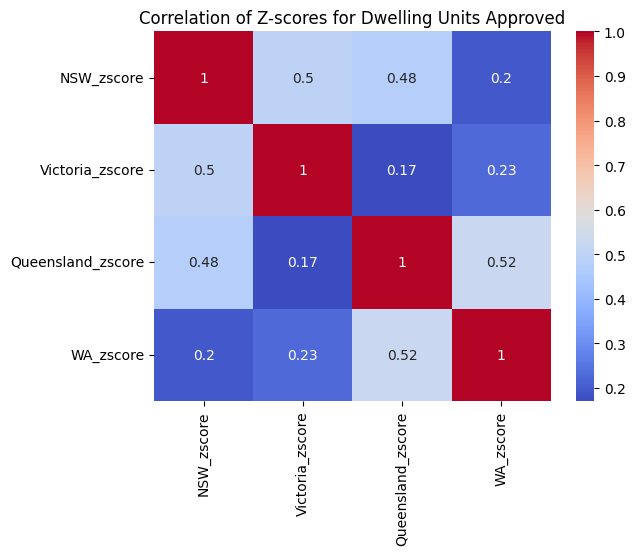

In [52]:
import seaborn as sns
zscore_cols = [f'{state}_zscore' for state in states]
sns.heatmap(df[zscore_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of Z-scores for Dwelling Units Approved')